In [9]:
import torch
from facenet_pytorch import InceptionResnetV1, MTCNN
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

## Load Data

In [10]:
lfw_people = fetch_lfw_people(color=True, resize=1.0, funneled=True, download_if_missing=True)
images = lfw_people.images  # shape: (n, h, w, 3), float32 [0,1]
labels = lfw_people.target
label_names = lfw_people.target_names
print(f"Loaded {len(images)} images of {len(label_names)} people.")

def to_pil_image(img_array):
    # The images come in float32 [0,1] — convert safely
    img_array = np.clip(img_array * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(img_array, mode='RGB')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Loaded 13233 images of 5749 people.
Using device: cpu


## Load Pretrained model

In [11]:
mtcnn = MTCNN(image_size=160, margin=0, keep_all=False, post_process=True, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [ ]:
def get_embedding(pil_img):
    with torch.no_grad():
        img_tensor = mtcnn(pil_img)
        if img_tensor is None:
            return None
        emb = model(img_tensor.unsqueeze(0).to(device))
    return emb.cpu().numpy()


## Testing 

### Random 2 images

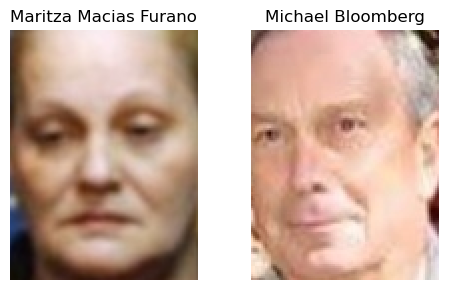

Cosine similarity: 0.013
Ground truth: Different people


In [19]:
# Pick two random samples
idx1, idx2 = random.sample(range(len(images)), 2)
img1 = to_pil_image(images[idx1])
img2 = to_pil_image(images[idx2])
label1 = label_names[labels[idx1]]
label2 = label_names[labels[idx2]]

fig, axes = plt.subplots(1, 2, figsize=(5,3))
axes[0].imshow(img1)
axes[0].set_title(label1)
axes[1].imshow(img2)
axes[1].set_title(label2)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

if emb1 is not None and emb2 is not None:
    sim = cosine_similarity(emb1, emb2)[0][0]
    print(f"Cosine similarity: {sim:.3f}")
    print("Ground truth:", "Same person" if label1 == label2 else "Different people")
else:
    print("⚠️ Could not detect a face in one of the images — try re-running.")


### Same person on the images

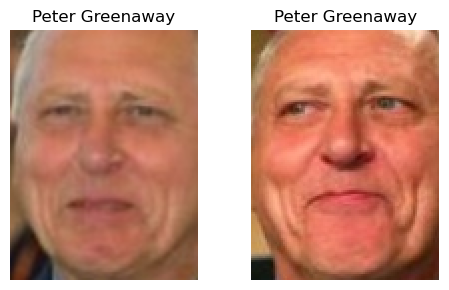

Cosine similarity: 0.850
These images are of the same person: Peter Greenaway


In [24]:
# Find a label with at least 2 images
unique, counts = np.unique(labels, return_counts=True)
eligible_labels = unique[counts >= 2]
chosen_label = random.choice(eligible_labels)

# Get all indices for this person
person_indices = np.where(labels == chosen_label)[0]
idx1, idx2 = random.sample(list(person_indices), 2)

# Load images
img1 = to_pil_image(images[idx1])
img2 = to_pil_image(images[idx2])
person_name = label_names[chosen_label]

# Display images
fig, axes = plt.subplots(1, 2, figsize=(5,3))
axes[0].imshow(img1)
axes[0].set_title(person_name)
axes[1].imshow(img2)
axes[1].set_title(person_name)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

if emb1 is not None and emb2 is not None:
    sim = cosine_similarity(emb1, emb2)[0][0]
    print(f"Cosine similarity: {sim:.3f}")
    print(f"These images are of the same person: {person_name}")
else:
    print("⚠️ Could not detect a face in one of the images.")